# CR-39 Nuclear Track Detector — Optimized Data Analysis

**Experiment:** d + ¹³C, 125–50 µm Ta filter, W146, 5 hr, 40×, backside  
**Scan file:** `A20251217_13CD_125-50umTaFilter_W146_5hr_40x_backside_s0_B.cpsa`

This notebook performs a complete, end-to-end analysis of CR-39 scan data:
1. **Loads** the binary `.cpsa` file with a fast NumPy-based reader
2. **Explores** raw track distributions to guide cut selection
3. **Applies** quality cuts (diameter, contrast, eccentricity, spatial bounds)
4. **Visualizes** the filtered 2D track density with x/y projections
5. **Computes** signal and background track counts with area-scaling subtraction
6. **Summarizes** all key statistics in one place

> All plots are saved to `plots/` in the analysis directory.

## 1. Imports

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import struct

# ── Numerical & data ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Plotting ──────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import AutoMinorLocator

# ── Progress bar (optional) ───────────────────────────────────────────────────
try:
    from tqdm import tqdm
except ImportError:
    def tqdm(x, *args, **kwargs):
        return x

# ── Global plot style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.size': 13,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'figure.dpi': 150,
})

print('Imports OK')

Imports OK


## 2. Configuration

Edit **only this cell** to change the file path, quality cuts, or region bounds.  
Everything downstream will update automatically.

In [2]:
# ── File path ─────────────────────────────────────────────────────────────────
# Path to the .cpsa binary scan file (relative to this notebook's directory)
  # UPDATE: Changed from absolute Mac path to a relative path pointing to your local
  # CR-39 scan data so that this notebook runs out-of-the-box on your machine.
CPSA_FILE = (
    "../CR-39_data/A20260413_13CD_125-50umTaFilter_W75_5hr_40x_backside_s0.cpsa"
)

# ── Quality cuts (applied during file parsing — very fast) ─────────────────────
  # UPDATE: Set D_MAX to 13.0 um (originally 17.5 um). This filters out larger
  # background noise (like dust, defects, or slow heavy ions) to isolate the 5.6 MeV protons.
D_MIN,  D_MAX  =  2.0, 13.0   # Track diameter bounds   (µm)
E_MIN,  E_MAX  =  0,   15     # Eccentricity bounds     (raw units, int8)
C_MIN,  C_MAX  =  0,   20     # Normal contrast bounds  (raw units, int8)
X_MIN,  X_MAX  = -2.5,  2.5   # Spatial x bounds        (cm)
Y_MIN,  Y_MAX  = -2.5,  2.5   # Spatial y bounds        (cm)

# ── Signal region (rectangular, drawn in red) ─────────────────────────────────
SIG_XMIN, SIG_XMAX = -1.5,  1.5
SIG_YMIN, SIG_YMAX = -1.5,  1.4

# ── Background strip (same x width, above signal region, drawn in blue) ────────
BG_XMIN,  BG_XMAX  = -1.5,  1.5
BG_YMIN,  BG_YMAX  =  1.5,  1.9

# ── Histogram binning ─────────────────────────────────────────────────────────
BINS_XY = 100   # 2D spatial histogram bins per axis
BINS_D  = 100   # Diameter distribution bins
BINS_R  = 100   # Radial distribution bins
BINS_C  =  50   # Contrast distribution bins

# ── Output directory for saved figures ───────────────────────────────────────
PLOT_DIR = "plots"
os.makedirs(PLOT_DIR, exist_ok=True)

print(f'Config OK — saving plots to "{PLOT_DIR}/')

Config OK — saving plots to "plots/


## 3. Optimized ScanData Reader

Key optimisations over the original `reader.py`:
- **Bulk NumPy reads** (`np.frombuffer`) replace per-element `struct.unpack` calls — up to ~20× faster on large scans
- **Vectorised filtering** with boolean NumPy masks instead of Python `if` per track
- **Single DataFrame construction** at the end (no incremental `pd.concat` inside the loop)
- Removed unused `frame_buffer_size` / `track_buffer_size` paging parameters

In [3]:
class ScanData:
    """
    Fast reader for CR-39 CPSA binary scan files.

    Parameters
    ----------
    path       : str   – Path to the .cpsa file.
    d_bounds   : (min, max) – Diameter filter in µm.
    e_bounds   : (min, max) – Eccentricity filter (raw int8).
    c_bounds   : (min, max) – Normal contrast filter (raw int8).
    a_bounds   : (min, max) – Average contrast filter (raw int8).
    x_bounds   : (min, max) – Spatial x filter in cm.
    y_bounds   : (min, max) – Spatial y filter in cm.

    Attributes
    ----------
    header  : dict       – Scan metadata (pixel size, frame dimensions, …)
    frames  : DataFrame  – Per-frame info (position, num_tracks, focus, …)
    tracks  : DataFrame  – Track data (d, x, y, e, c, a, frame_number)
    trailer : str        – ASCII trailer appended by the scanner software.
    """

    def __init__(self, path,
                 d_bounds=(0, np.inf),
                 e_bounds=(0, np.inf),
                 c_bounds=(0, np.inf),
                 a_bounds=(0, np.inf),
                 x_bounds=(-np.inf, np.inf),
                 y_bounds=(-np.inf, np.inf)):
        self.header  = {}
        self.frames  = None
        self.tracks  = None
        self.trailer = ''

        with open(path, 'rb') as f:
            self._parse_header(f)
            self._parse_data(f, d_bounds, e_bounds, c_bounds,
                             a_bounds, x_bounds, y_bounds)
            self._parse_trailer(f)

    # ── Helper: read a little-endian int32 ────────────────────────────────────
    @staticmethod
    def _ri(f):
        return struct.unpack('<i', f.read(4))[0]

    @staticmethod
    def _rf(f):
        return struct.unpack('<f', f.read(4))[0]

    # ── Header (48 bytes) ─────────────────────────────────────────────────────
    def _parse_header(self, f):
        ri, rf = self._ri, self._rf
        ps = 1e-4 * rf(f)  # pixel size in cm — read after version/dim fields below

        # Re-read in correct order (version_number is field 0)
        f.seek(0)  # rewind
        h = {
            'version_number':     ri(f),
            'num_x_frames':       ri(f),
            'num_y_frames':       ri(f),
            'num_bins':           ri(f),
            'pixel_size':   1e-4 * rf(f),   # cm per pixel
            'pixels_per_bin':     rf(f),
            'border_limit':       ri(f),
            'contrast_limit':     ri(f),
            'eccentricity_limit': ri(f),
            'M':                  ri(f),
            'frame_width':        ri(f),    # in pixels — converted below
            'frame_height':       ri(f),    # in pixels — converted below
        }
        ps = h['pixel_size']
        h['frame_width']  *= ps   # → cm
        h['frame_height'] *= ps   # → cm
        self.header = h

    # ── Frame + track data ────────────────────────────────────────────────────
    def _parse_data(self, f, d_bounds, e_bounds, c_bounds,
                   a_bounds, x_bounds, y_bounds):
        ps = self.header['pixel_size']
        fw = self.header['frame_width']
        fh = self.header['frame_height']
        num_frames = self.header['num_x_frames'] * self.header['num_y_frames']

        frame_rows = []   # collect frame metadata
        track_chunks = [] # collect filtered track arrays (one ndarray per frame)

        for _ in tqdm(range(num_frames), desc='Reading frames', unit='fr'):
            # ── Frame header (28 bytes) ────────────────────────────────────
            number      = struct.unpack('<i', f.read(4))[0]
            x_pos       = 1e-5 * struct.unpack('<i', f.read(4))[0]  # cm
            y_pos       = 1e-5 * struct.unpack('<i', f.read(4))[0]  # cm
            num_tracks  = struct.unpack('<i', f.read(4))[0]
            f.read(12)   # skip 3 unused int32 fields
            focus       = 1e-2 * struct.unpack('<i', f.read(4))[0]  # µm
            xi          = struct.unpack('<i', f.read(4))[0]          # x index
            yi          = struct.unpack('<i', f.read(4))[0]          # y index

            frame_rows.append((number, x_pos, y_pos, num_tracks,
                               focus, xi, yi))

            if num_tracks == 0:
                continue

            # ── Bulk-read all six track arrays at once ─────────────────────
            # Layout in file: d[n], e[n], c[n], a[n], x[n], y[n]
            d_raw = np.frombuffer(f.read(2 * num_tracks), dtype='<i2')  # int16 → µm after scale
            e_raw = np.frombuffer(f.read(num_tracks),     dtype='<i1')  # int8  eccentricity
            c_raw = np.frombuffer(f.read(num_tracks),     dtype='<i1')  # int8  normal contrast
            a_raw = np.frombuffer(f.read(num_tracks),     dtype='<i1')  # int8  average contrast
            x_raw = np.frombuffer(f.read(2 * num_tracks), dtype='<i2')  # int16 pixel position
            y_raw = np.frombuffer(f.read(2 * num_tracks), dtype='<i2')  # int16 pixel position

            # ── Unit conversion (vectorised) ───────────────────────────────
            d_um = 100.0 * d_raw * ps         # diameter in µm
            x_cm = x_pos - 0.5*fw + x_raw*ps  # absolute x in cm
            y_cm = y_pos - 0.5*fh + y_raw*ps  # absolute y in cm

            # ── Vectorised quality + spatial filter ────────────────────────
            mask = (
                (d_um  >= d_bounds[0]) & (d_um  <= d_bounds[1]) &
                (e_raw >= e_bounds[0]) & (e_raw <= e_bounds[1]) &
                (c_raw >= c_bounds[0]) & (c_raw <= c_bounds[1]) &
                (a_raw >= a_bounds[0]) & (a_raw <= a_bounds[1]) &
                (x_cm  >= x_bounds[0]) & (x_cm  <= x_bounds[1]) &
                (y_cm  >= y_bounds[0]) & (y_cm  <= y_bounds[1])
            )

            n_pass = mask.sum()
            if n_pass == 0:
                continue

            # Pack selected tracks into a (n_pass × 7) float64 array
            chunk = np.empty((n_pass, 7), dtype=np.float64)
            chunk[:, 0] = number          # frame_number (stored as float, cast later)
            chunk[:, 1] = d_um[mask]      # d  [µm]
            chunk[:, 2] = x_cm[mask]      # x  [cm]
            chunk[:, 3] = y_cm[mask]      # y  [cm]
            chunk[:, 4] = e_raw[mask]     # e  (eccentricity)
            chunk[:, 5] = c_raw[mask]     # c  (normal contrast)
            chunk[:, 6] = a_raw[mask]     # a  (average contrast)
            track_chunks.append(chunk)

        # ── Build DataFrames once at the end (avoids costly pd.concat in loop) ─
        self.frames = pd.DataFrame(frame_rows, columns=[
            'number', 'x_position', 'y_position', 'num_tracks',
            'focus', 'x_position_index', 'y_position_index'
        ])

        if track_chunks:
            arr = np.vstack(track_chunks)
            self.tracks = pd.DataFrame(arr, columns=[
                'frame_number', 'd', 'x', 'y', 'e', 'c', 'a'
            ])
            # Restore compact dtypes to save memory
            self.tracks['frame_number'] = self.tracks['frame_number'].astype(np.int32)
            self.tracks[['e', 'c', 'a']] = self.tracks[['e', 'c', 'a']].astype(np.int8)
            self.tracks[['d', 'x', 'y']] = self.tracks[['d', 'x', 'y']].astype(np.float32)
        else:
            self.tracks = pd.DataFrame(
                columns=['frame_number', 'd', 'x', 'y', 'e', 'c', 'a'])

    # ── Trailer (ASCII metadata appended by scanner) ──────────────────────────
    def _parse_trailer(self, f):
        f.read(4)  # skip 4-byte separator
        self.trailer = f.read().decode('latin-1')

    def __repr__(self):
        h = self.header
        return (
            f'ScanData  {h["num_x_frames"]}×{h["num_y_frames"]} frames  '
            f'pixel={h["pixel_size"]*1e4:.4f} µm  '
            f'tracks={len(self.tracks):,}'
        )


print('ScanData class defined')

ScanData class defined


## 4. Load Data

In [4]:
# Load the CPSA file.  All quality + spatial cuts are applied during parsing.
data = ScanData(
    CPSA_FILE,
    d_bounds=(D_MIN, D_MAX),
    e_bounds=(E_MIN, E_MAX),
    c_bounds=(C_MIN, C_MAX),
    x_bounds=(X_MIN, X_MAX),
    y_bounds=(Y_MIN, Y_MAX),
)

tracks = data.tracks   # shorthand — used throughout the notebook
frames = data.frames

# ── Quick summary ─────────────────────────────────────────────────────────────
h = data.header
print(data)
print(f"\nScan grid  : {h['num_x_frames']} × {h['num_y_frames']} = "
      f"{h['num_x_frames']*h['num_y_frames']:,} frames")
print(f"Pixel size : {h['pixel_size']*1e4:.4f} µm")
print(f"Frame size : {h['frame_width']*1e4:.1f} × {h['frame_height']*1e4:.1f} µm")
print(f"\nTracks loaded (after cuts): {len(tracks):,}")
print(f"Track columns : {list(tracks.columns)}")
print(f"Memory usage  : {tracks.memory_usage(deep=True).sum()/1e6:.2f} MB")
print()
print(tracks.describe().round(3))

ScanData  106×144 frames  pixel=0.3280 µm  tracks=120,469

Scan grid  : 106 × 144 = 15,264 frames
Pixel size : 0.3280 µm
Frame size : 444.1 × 328.7 µm

Tracks loaded (after cuts): 120,469
Track columns : ['frame_number', 'd', 'x', 'y', 'e', 'c', 'a']
Memory usage  : 2.29 MB

       frame_number           d           x           y           e  \
count    120469.000  120469.000  120469.000  120469.000  120469.000   
mean       8196.719       7.571      -0.030      -0.174       4.153   
std        3650.326       2.696       1.147       1.132       3.915   
min         151.000       2.027      -2.328      -2.364       0.000   
25%        5381.000       5.550      -0.947      -1.094       1.000   
50%        8353.000       7.485      -0.042      -0.223       3.000   
75%       11168.000       9.650       0.884       0.698       6.000   
max       15212.000      12.999       2.335       2.333      15.000   

                c           a  
count  120469.000  120469.000  
mean       11.675   

In [5]:
frames

,number,x_position,y_position,num_tracks,focus,x_position_index,y_position_index
0,1,-2.34999,2.34999,0,3.77,0,0
1,2,-2.30558,2.34999,0,3.77,1,0
2,3,-2.26117,2.34999,0,3.77,2,0
3,4,-2.21676,2.34999,0,3.77,3,0
4,5,-2.17235,2.34999,0,3.77,4,0
...,...,...,...,...,...,...,...
15259,15260,-2.17235,-2.34899,0,52.60,4,143
15260,15261,-2.21676,-2.34899,0,52.60,3,143
15261,15262,-2.26117,-2.34899,0,52.60,2,143
15262,15263,-2.30558,-2.34899,0,52.60,1,143


In [6]:
area_CR_39= np.pi*2.5**2
tracks=34183

In [7]:
#Tracks per cm^2  
tracks_per_cm2 = tracks/area_CR_39
tracks_per_cm2

1740.9258943072825

## 5. Pre-Cut Exploration — Diameter vs. Contrast

Load the file **without** quality cuts to see the full raw distribution.  
This helps verify that the cuts in §2 are placed correctly.

In [8]:
# Load raw data (no quality cuts, only loose spatial bounds to stay in detector)
data_raw = ScanData(CPSA_FILE, x_bounds=(X_MIN, X_MAX), y_bounds=(Y_MIN, Y_MAX))
tr = data_raw.tracks
print(f'Raw tracks (no quality cuts): {len(tr):,}')

Raw tracks (no quality cuts): 530,122


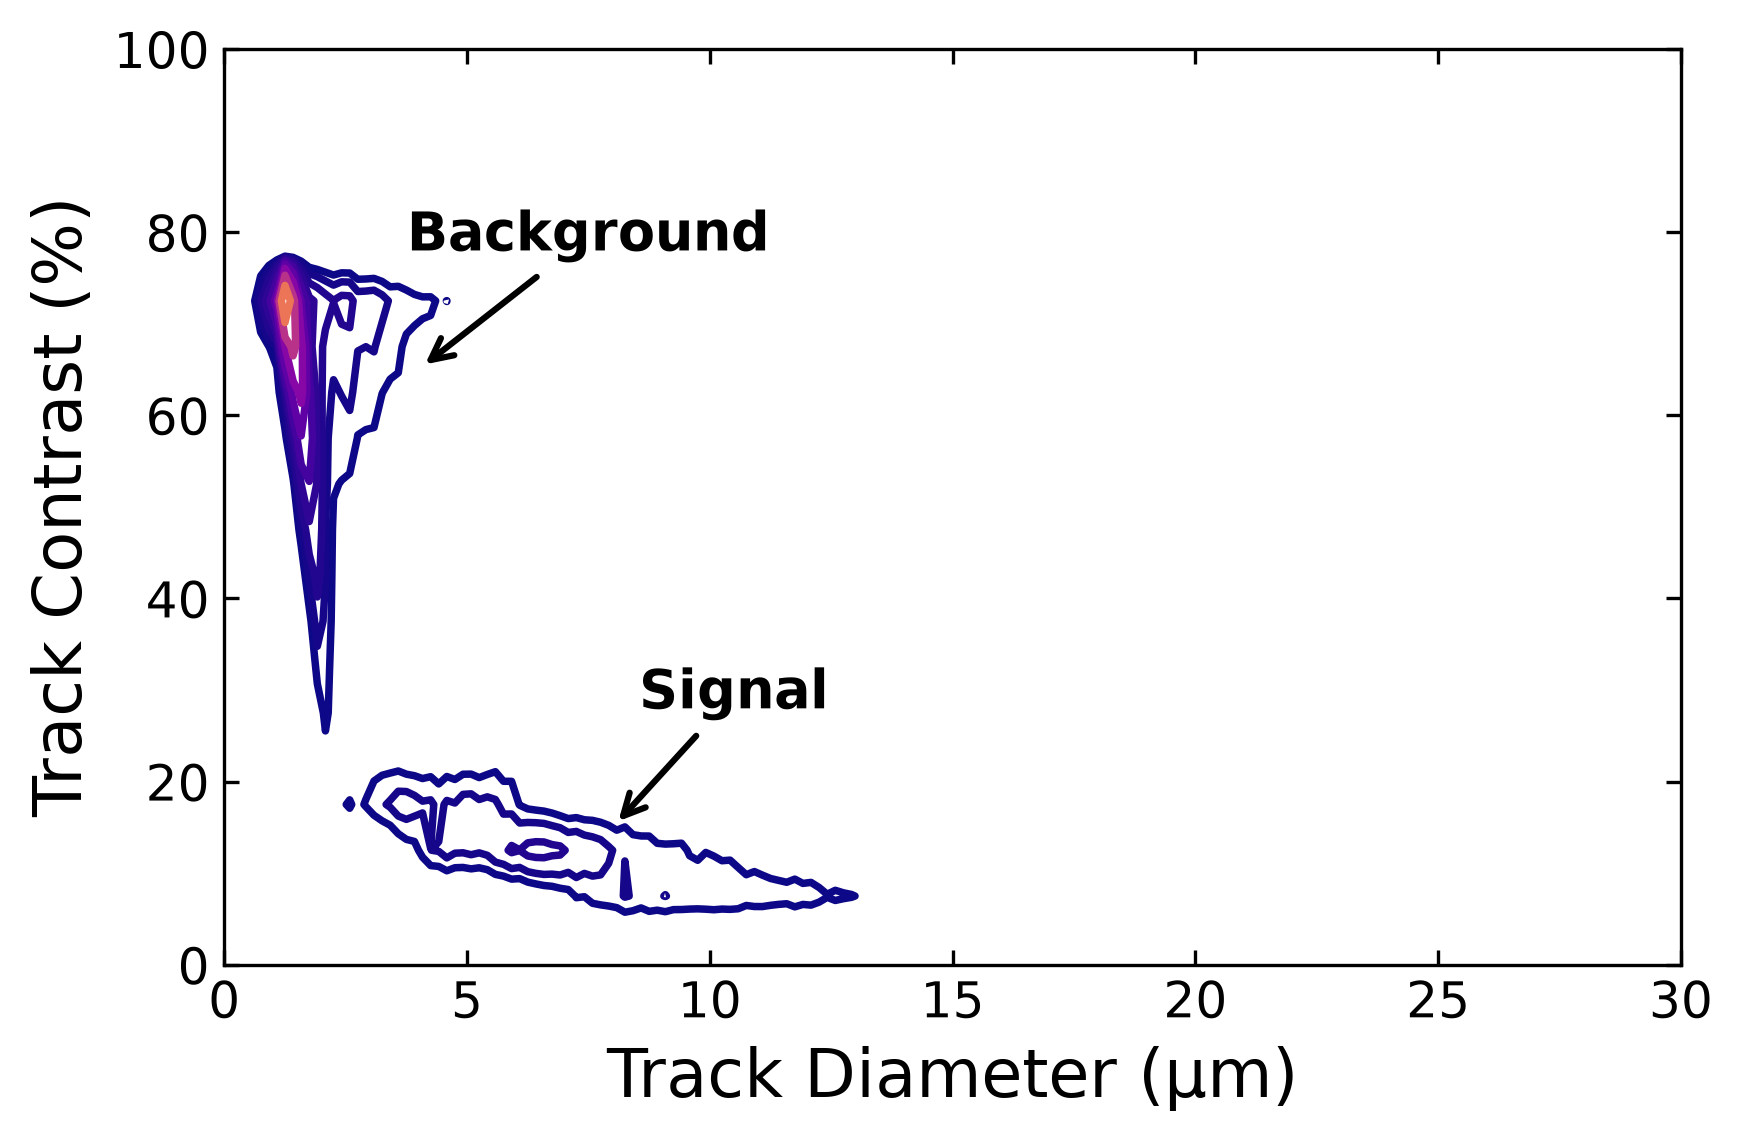

In [9]:
# ── Diameter vs. Normal-Contrast contour (raw, no quality cuts) ───────────────
# Use this plot to choose D_MIN/D_MAX and C_MAX in the config cell.

fig, ax = plt.subplots(figsize=(6,4),dpi=300)

H, xedges, yedges = np.histogram2d(tr['d'], tr['c'],
                                    bins=[150, 100],
                                    range=[[0, 25], [0, 500]])
xc = 0.5 * (xedges[:-1] + xedges[1:])
yc = 0.5 * (yedges[:-1] + yedges[1:])

MIN_COUNT = 800
if H.max() > MIN_COUNT:
    levels = np.logspace(np.log10(MIN_COUNT), np.log10(H.max()), 10)
    cs = ax.contour(xc, yc, H.T, levels=levels, cmap='plasma', linewidths=1.8)
    #fig.colorbar(cs, ax=ax, label='Counts per bin')

# Overlay the cut boundaries used in analysis
#ax.axvline(D_MIN, color='lime',  lw=1.5, ls='--', label=f'd_min = {D_MIN} µm')
#ax.axvline(D_MAX, color='cyan',  lw=1.5, ls='--', label=f'd_max = {D_MAX} µm')
#ax.axhline(C_MAX, color='red',   lw=1.5, ls='--', label=f'c_max = {C_MAX}')

ax.set_xlim(0, 30)
ax.set_ylim(0, 100)
ax.set_xlabel('Track Diameter (µm)',fontsize=16)
ax.set_ylabel('Track Contrast (%)',fontsize=16)
#ax.set_title('Raw: Diameter vs. Contrast  (cut lines shown)')
#ax.legend(fontsize=11, loc='upper right')
arrow_props = dict(arrowstyle='->', color='black', lw=1.5)
ax.annotate('Signal',
            xy=(8, 15),           # arrow tip  → tweak to your lower island peak
            xytext=(10.5, 28),    # label position
            fontsize=13, color='black', fontweight='bold',
            arrowprops=arrow_props,
            ha='center')

# Upper island → Background
ax.annotate('Background',
            xy=(4, 65),           # arrow tip  → tweak to your upper island peak
            xytext=(7.5, 78),     # label position
            fontsize=13, color='black', fontweight='bold',
            arrowprops=arrow_props,
            ha='center')
fig.tight_layout()
#fig.savefig(f'{PLOT_DIR}/00_precut_d_vs_contrast.png', dpi=300)
plt.show()

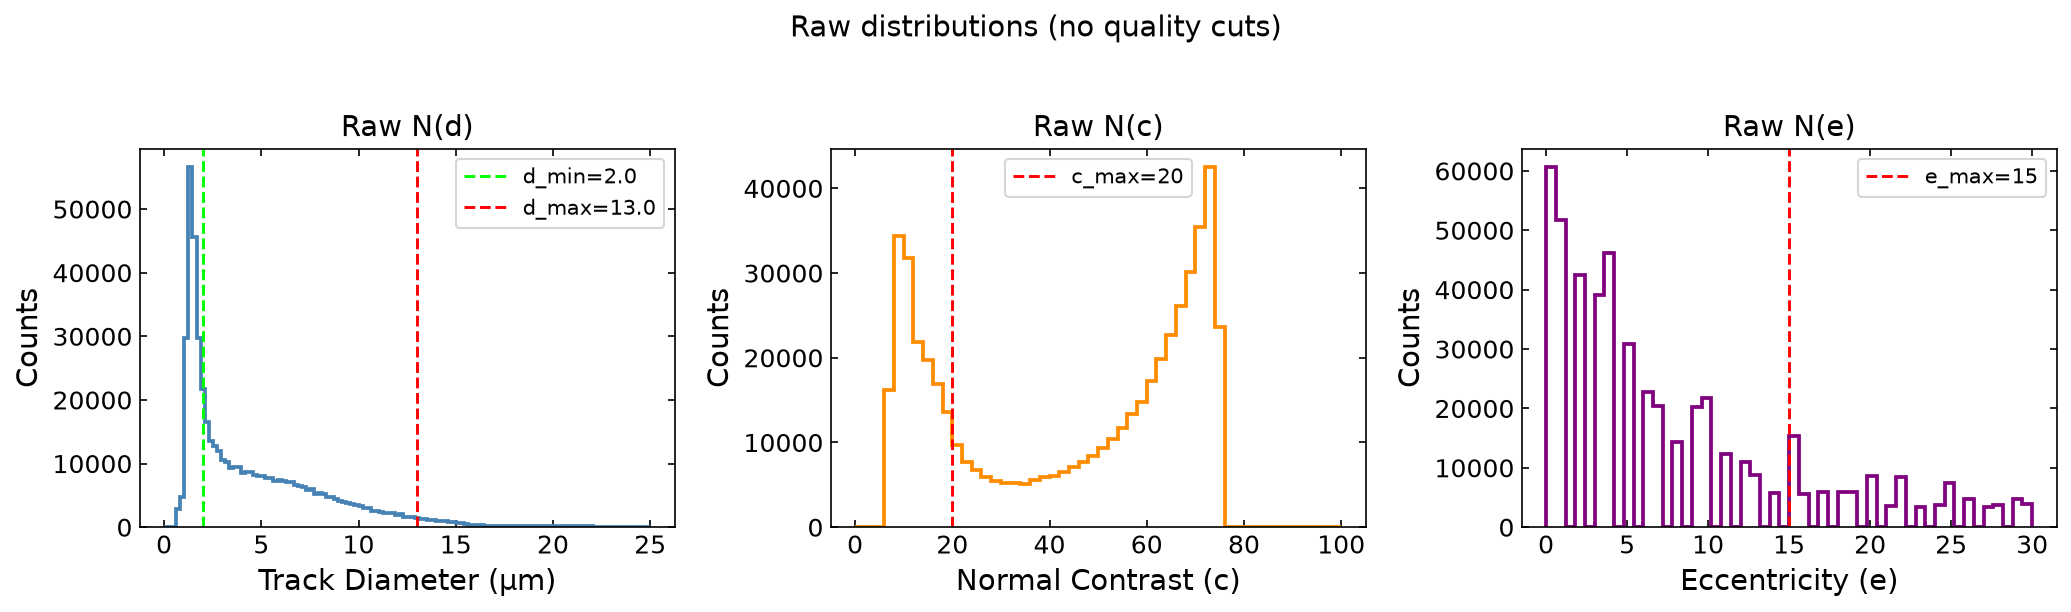

In [10]:
# ── Raw 1D distributions of d, c, and e ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(tr['d'], bins=120, range=(0, 25), histtype='step', lw=1.8, color='steelblue')
axes[0].axvline(D_MIN, color='lime', ls='--', lw=1.4, label=f'd_min={D_MIN}')
axes[0].axvline(D_MAX, color='red',  ls='--', lw=1.4, label=f'd_max={D_MAX}')
axes[0].set_xlabel('Track Diameter (µm)')
axes[0].set_ylabel('Counts')
axes[0].set_title('Raw N(d)')
axes[0].legend(fontsize=10)

axes[1].hist(tr['c'], bins=BINS_C, range=(0, 100), histtype='step', lw=1.8, color='darkorange')
axes[1].axvline(C_MAX, color='red', ls='--', lw=1.4, label=f'c_max={C_MAX}')
axes[1].set_xlabel('Normal Contrast (c)')
axes[1].set_ylabel('Counts')
axes[1].set_title('Raw N(c)')
axes[1].legend(fontsize=10)

axes[2].hist(tr['e'], bins=50, range=(0, 30), histtype='step', lw=1.8, color='purple')
axes[2].axvline(E_MAX, color='red', ls='--', lw=1.4, label=f'e_max={E_MAX}')
axes[2].set_xlabel('Eccentricity (e)')
axes[2].set_ylabel('Counts')
axes[2].set_title('Raw N(e)')
axes[2].legend(fontsize=10)

fig.suptitle('Raw distributions (no quality cuts)', y=1.02, fontsize=14)
fig.tight_layout()
#fig.savefig(f'{PLOT_DIR}/01_precut_1D_distributions.png', dpi=300)
plt.show()


C:\Users\sayak\AppData\Local\Temp\ipykernel_11928\3860695603.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10)


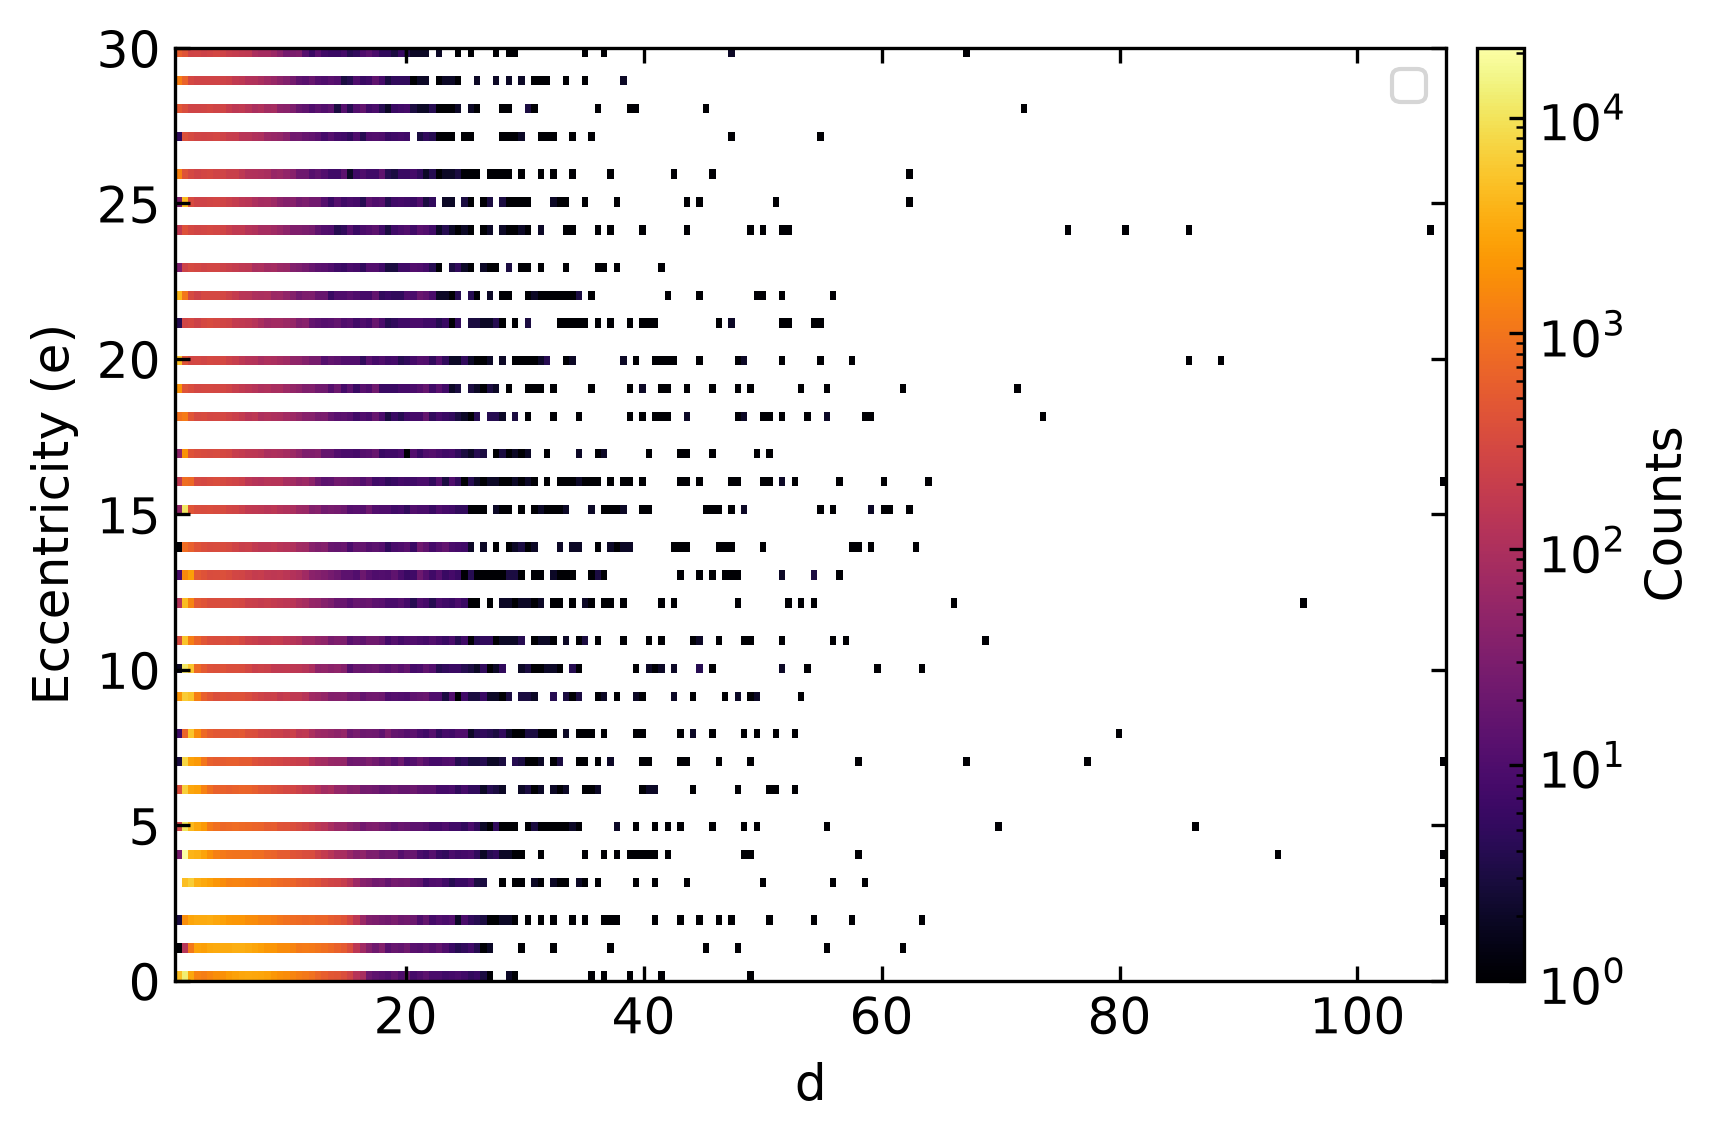

In [11]:
import matplotlib.colors as mcolors

# ── 2D Heatmap: Eccentricity vs X (counts on z-axis) ─────────────────────────
fig, ax = plt.subplots(figsize=(6, 4),dpi=300)

h, xedges, yedges, img = ax.hist2d(
    tr['d'], tr['e'],
    bins=[200, 100],
    range=[[tr['d'].min(), tr['d'].max()], [0, 30]],
    cmap='inferno',
    norm=mcolors.LogNorm(vmin=1)
)

cbar = fig.colorbar(img, ax=ax, pad=0.02)
cbar.set_label('Counts', fontsize=12)

# Optional: overlay the E_MAX cut line
#ax.axhline(E_MAX, color='cyan', ls='--', lw=1.4, label=f'e_max = {E_MAX}')
ax.legend(fontsize=10)

ax.set_xlabel('d', fontsize=12)
ax.set_ylabel('Eccentricity (e)', fontsize=12)
#ax.set_title('Heatmap: Eccentricity vs X  [raw counts]', fontsize=14)

fig.tight_layout()
#plt.yscale("log")
#fig.savefig(f'{PLOT_DIR}/heatmap_eccentricity_vs_x.png', dpi=300)
plt.show()

## 6. Track Density Map with Projections

2D spatial histogram of all tracks passing the quality cuts,  
with marginal x (top) and y (right) projections.

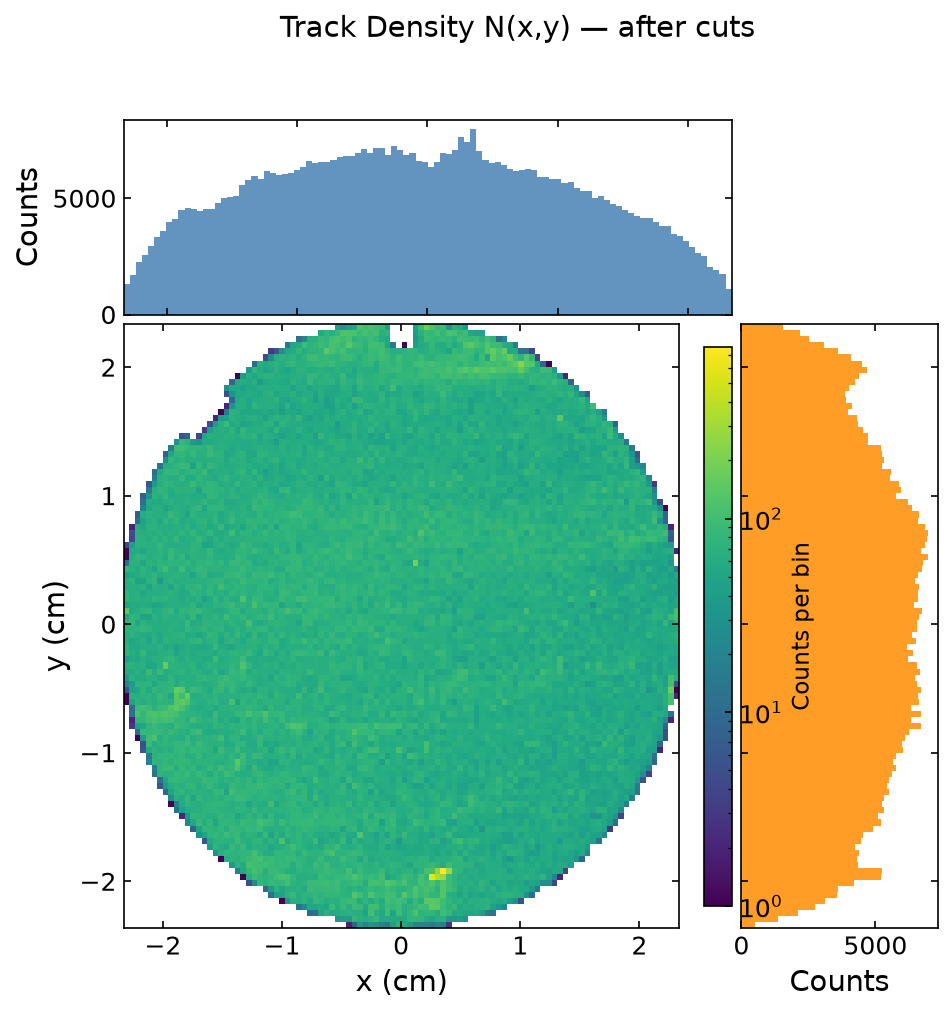

In [12]:
x = tr['x']
y = tr['y']

# ── Layout: 4×4 GridSpec — main 2D plot + two marginal projections ─────────
fig = plt.figure(figsize=(7, 7))
gs  = GridSpec(4, 4, figure=fig, hspace=0.05, wspace=0.05)

ax_main  = fig.add_subplot(gs[1:4, 0:3])
ax_xproj = fig.add_subplot(gs[0,   0:3], sharex=ax_main)
ax_yproj = fig.add_subplot(gs[1:4, 3],   sharey=ax_main)

# ── Main 2D histogram (log colour scale) ─────────────────────────────────────
h2d = ax_main.hist2d(x, y, bins=BINS_XY, norm=LogNorm(), cmap='viridis')
cbar = fig.colorbar(h2d[3], ax=ax_main, fraction=0.046, pad=0.04)
cbar.set_label('Counts per bin', fontsize=11)

ax_main.set_xlabel('x (cm)')
ax_main.set_ylabel('y (cm)')
ax_main.tick_params(which='both', direction='in', top=True, right=True)

# ── X projection (top panel) ─────────────────────────────────────────────────
cx, bx = np.histogram(x, bins=BINS_XY)
bxc    = 0.5 * (bx[:-1] + bx[1:])
ax_xproj.bar(bxc, cx, width=bx[1]-bx[0], color='steelblue', alpha=0.85)
ax_xproj.set_ylabel('Counts')
ax_xproj.tick_params(direction='in', labelbottom=False)

# ── Y projection (right panel) ────────────────────────────────────────────────
cy, by = np.histogram(y, bins=BINS_XY)
byc    = 0.5 * (by[:-1] + by[1:])
ax_yproj.barh(byc, cy, height=by[1]-by[0], color='darkorange', alpha=0.85)
ax_yproj.set_xlabel('Counts')
ax_yproj.tick_params(direction='in', labelleft=False)

fig.suptitle('Track Density N(x,y) — after cuts', y=0.98, fontsize=14)
#fig.savefig(f'{PLOT_DIR}/02_track_density_with_projections.png', dpi=300,bbox_inches='tight')
plt.show()

## 7. Track Density Map with Projections with cuts 

2D spatial histogram of all tracks with the quality cuts,  
with marginal x (top) and y (right) projections.

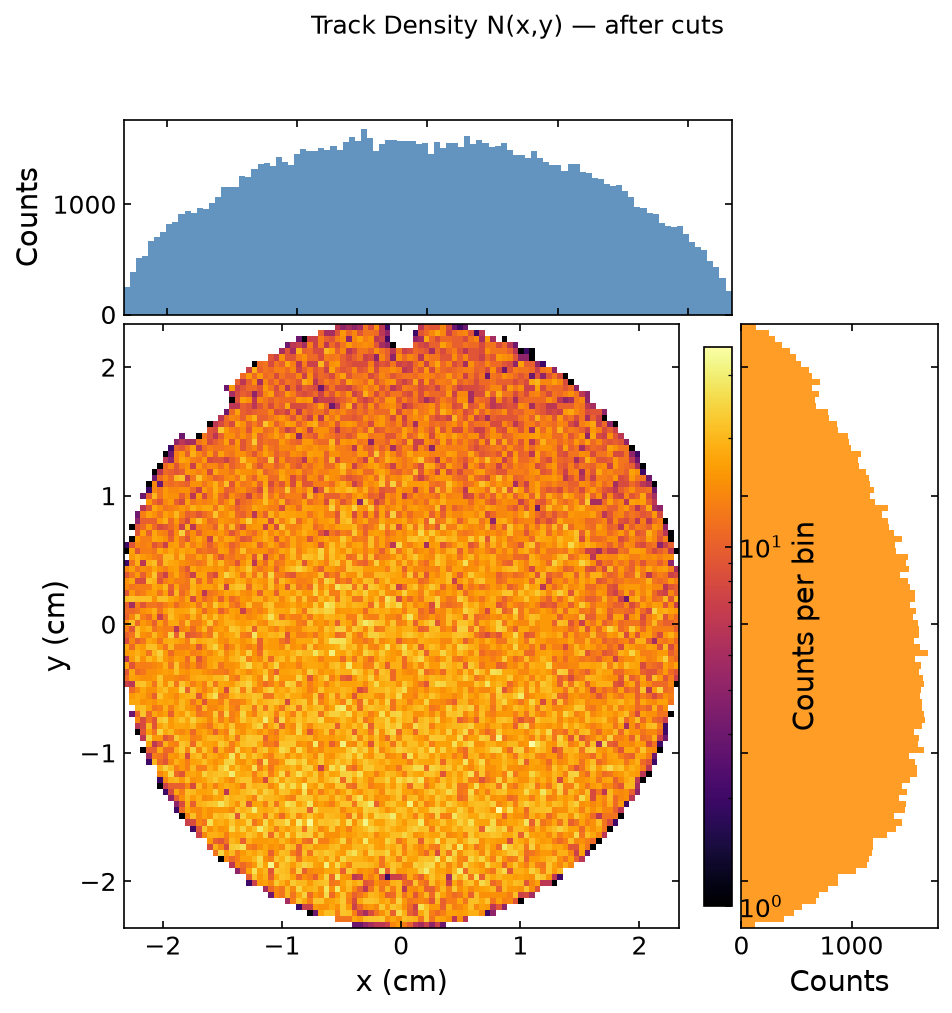

In [13]:
# Re-load with the latest cuts (in case you tweaked them above) and re-plot.
data  = ScanData(
    CPSA_FILE,
    d_bounds=(D_MIN, D_MAX),
    e_bounds=(E_MIN, E_MAX),
    c_bounds=(C_MIN, C_MAX),
    x_bounds=(X_MIN, X_MAX),
    y_bounds=(Y_MIN, Y_MAX),
)
tracks = data.tracks
x_cut, y_cut = tracks['x'], tracks['y']

fig = plt.figure(figsize=(7, 7), dpi=150)
gs  = GridSpec(4, 4, figure=fig, hspace=0.05, wspace=0.05)
ax_main  = fig.add_subplot(gs[1:4, 0:3])
ax_xproj = fig.add_subplot(gs[0,   0:3], sharex=ax_main)
ax_yproj = fig.add_subplot(gs[1:4, 3],   sharey=ax_main)

h2d = ax_main.hist2d(x_cut, y_cut, bins=BINS_XY, norm=LogNorm(), cmap='inferno')
fig.colorbar(h2d[3], ax=ax_main, fraction=0.046, pad=0.04, label='Counts per bin')
ax_main.set_xlabel('x (cm)'); ax_main.set_ylabel('y (cm)')

cx, bx = np.histogram(x_cut, bins=BINS_XY)
bxc    = 0.5 * (bx[:-1] + bx[1:])
ax_xproj.bar(bxc, cx, width=bx[1]-bx[0], color='steelblue', alpha=0.85)
ax_xproj.set_ylabel('Counts'); ax_xproj.tick_params(direction='in', labelbottom=False)

cy, by = np.histogram(y_cut, bins=BINS_XY)
byc    = 0.5 * (by[:-1] + by[1:])
ax_yproj.barh(byc, cy, height=by[1]-by[0], color='darkorange', alpha=0.85)
ax_yproj.set_xlabel('Counts'); ax_yproj.tick_params(direction='in', labelleft=False)

fig.suptitle(f'Track Density N(x,y) — after cuts', y=0.98, fontsize=12)
#fig.savefig(PLOT_DIR / '02b_track_density_after_cuts.png', dpi=300, bbox_inches='tight')
plt.show()


## 7. Signal & Background Region Analysis

- **Signal region** (red rectangle): the area containing the reaction products.
- **Background strip** (blue rectangle): a same-width strip above the signal region,  
  used to estimate the uniform background track density.
- Background is **area-scaled** to the signal region and subtracted.

In [14]:
#── Signal region (rectangular, drawn in red) ─────────────────────────────────
SIG_XMIN, SIG_XMAX = -1.5,  1.5
SIG_YMIN, SIG_YMAX = -1.8,  1.4

# ── Background strip (same x width, above signal region, drawn in blue) ────────
BG_XMIN,  BG_XMAX  = -1.4,  1.5
BG_YMIN,  BG_YMAX  =  1.5,  1.9



# ── Boolean masks for signal and background regions ───────────────────────────
sig_mask = (
    (x_cut >= SIG_XMIN) & (x_cut <= SIG_XMAX) &
    (y_cut >= SIG_YMIN) & (y_cut <= SIG_YMAX)
)
bg_mask = (
    (x_cut >= BG_XMIN) & (x_cut <= BG_XMAX) &
    (y_cut >= BG_YMIN) & (y_cut <= BG_YMAX)
)

N_sig_total = sig_mask.sum()   # total tracks inside signal rectangle
N_bg_strip  = bg_mask.sum()    # tracks in background strip

# Scale background to signal area
A_sig = (SIG_XMAX - SIG_XMIN) * (SIG_YMAX - SIG_YMIN)   # cm²
A_bg  = (BG_XMAX  - BG_XMIN)  * (BG_YMAX  - BG_YMIN)    # cm²
scale = A_sig / A_bg

N_bg_scaled     = N_bg_strip * scale       # expected background in signal box
N_signal_net    = N_sig_total - N_bg_scaled  # background-subtracted signal

print(f'Signal region  : x ∈ [{SIG_XMIN}, {SIG_XMAX}]  y ∈ [{SIG_YMIN}, {SIG_YMAX}]  → A = {A_sig:.4f} cm²')
print(f'Background strip: x ∈ [{BG_XMIN}, {BG_XMAX}]  y ∈ [{BG_YMIN}, {BG_YMAX}]  → A = {A_bg:.4f} cm²')
print(f'Area scale factor = A_sig / A_bg = {scale:.4f}')
print()
print(f'Tracks in signal box  (raw)     : {N_sig_total:>10,}')
print(f'Tracks in background strip      : {N_bg_strip:>10,}')
print(f'Scaled background in signal box : {N_bg_scaled:>10.1f}')
print(f'Background-subtracted signal    : {N_signal_net:>10.1f}')

# Poisson uncertainty on background-subtracted count
sigma_net = np.sqrt(N_sig_total + scale**2 * N_bg_strip)
print(f'Statistical uncertainty (±1σ)   : ± {sigma_net:.1f}')

Signal region  : x ∈ [-1.5, 1.5]  y ∈ [-1.8, 1.4]  → A = 9.6000 cm²
Background strip: x ∈ [-1.4, 1.5]  y ∈ [1.5, 1.9]  → A = 1.1600 cm²
Area scale factor = A_sig / A_bg = 8.2759

Tracks in signal box  (raw)     :     72,550
Tracks in background strip      :      5,949
Scaled background in signal box :    49233.1
Background-subtracted signal    :    23316.9
Statistical uncertainty (±1σ)   : ± 692.8


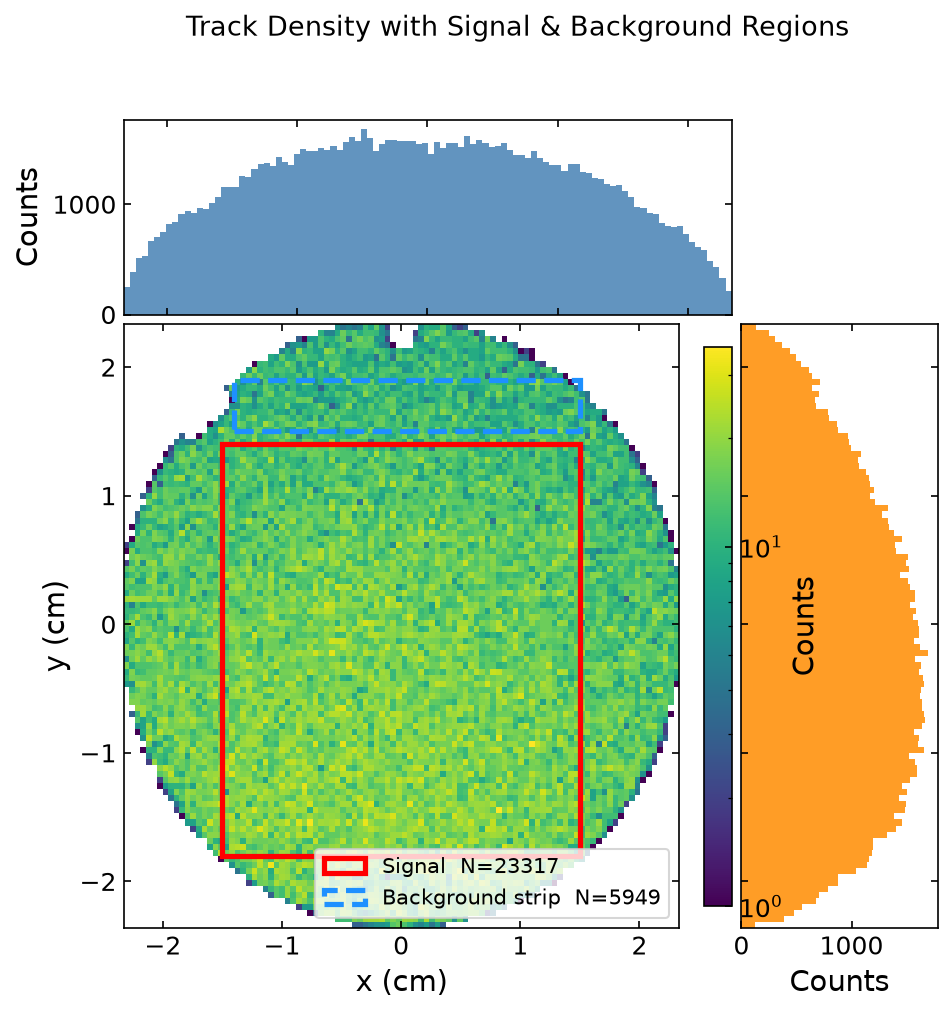

In [15]:
# ── Track density map with signal & background boxes overlaid ─────────────────
fig = plt.figure(figsize=(7, 7))
gs  = GridSpec(4, 4, figure=fig, hspace=0.05, wspace=0.05)

ax_main  = fig.add_subplot(gs[1:4, 0:3])
ax_xproj = fig.add_subplot(gs[0,   0:3], sharex=ax_main)
ax_yproj = fig.add_subplot(gs[1:4, 3],   sharey=ax_main)

# 2D histogram
h2d = ax_main.hist2d(x_cut, y_cut, bins=BINS_XY, norm=LogNorm(), cmap='viridis')
fig.colorbar(h2d[3], ax=ax_main, fraction=0.046, pad=0.04, label='Counts')

# Signal rectangle (red)
ax_main.add_patch(patches.Rectangle(
    (SIG_XMIN, SIG_YMIN),
    SIG_XMAX - SIG_XMIN, SIG_YMAX - SIG_YMIN,
    lw=2.5, edgecolor='red', facecolor='none',
    label=f'Signal  N={N_signal_net:.0f}'
))

# Background rectangle (blue)
ax_main.add_patch(patches.Rectangle(
    (BG_XMIN, BG_YMIN),
    BG_XMAX - BG_XMIN, BG_YMAX - BG_YMIN,
    lw=2.5, edgecolor='dodgerblue', facecolor='none', ls='--',
    label=f'Background strip  N={N_bg_strip}'
))

ax_main.set_xlabel('x (cm)')
ax_main.set_ylabel('y (cm)')
ax_main.legend(fontsize=10, loc='lower right')

# Projections
ax_xproj.bar(bxc, cx, width=bx[1]-bx[0], color='steelblue', alpha=0.85)
ax_xproj.set_ylabel('Counts')
ax_xproj.tick_params(direction='in', labelbottom=False)

ax_yproj.barh(byc, cy, height=by[1]-by[0], color='darkorange', alpha=0.85)
ax_yproj.set_xlabel('Counts')
ax_yproj.tick_params(direction='in', labelleft=False)

fig.suptitle('Track Density with Signal & Background Regions', y=0.98, fontsize=13)
#fig.savefig(f'{PLOT_DIR}/03_signal_background_regions.png', dpi=300, bbox_inches='tight')
plt.show()

X projection — Signal: 72550,  Background: 5949
Y projection — Signal: 72550,  Background: 5949
Signal mask total:     72550
Background mask total: 5949


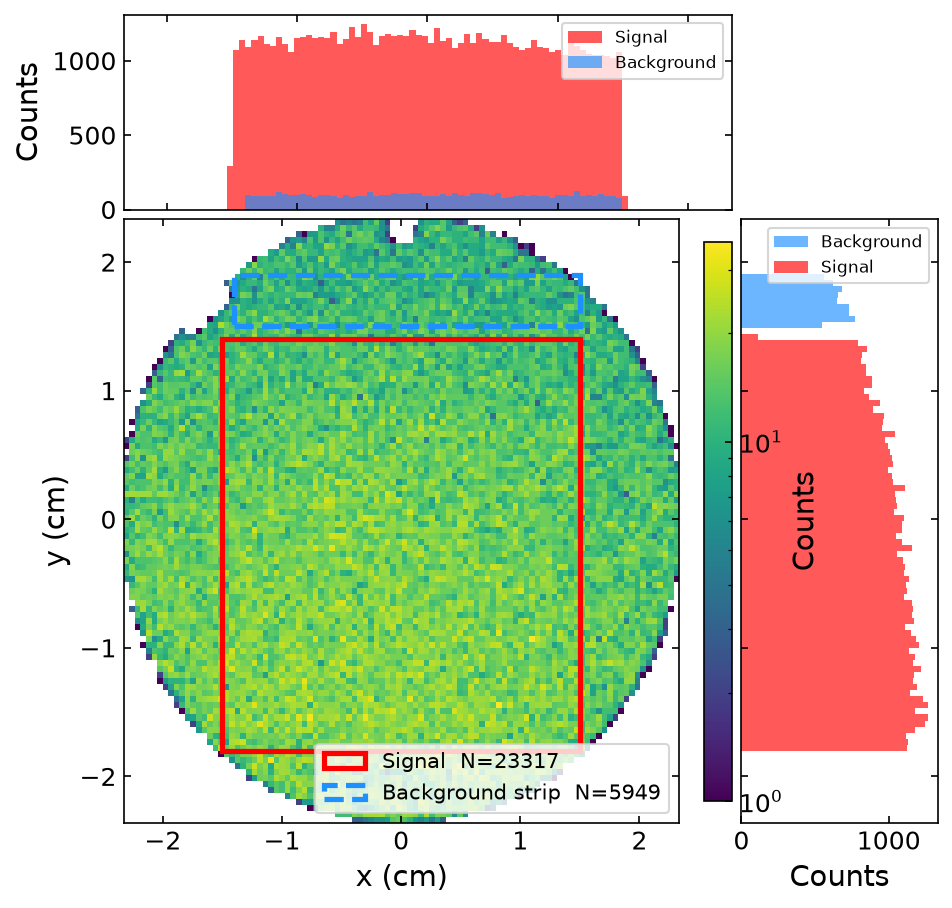

In [16]:
# ── Track density map with signal & background boxes overlaid ─────────────────
fig = plt.figure(figsize=(7, 7))
gs  = GridSpec(4, 4, figure=fig, hspace=0.05, wspace=0.05)
ax_main  = fig.add_subplot(gs[1:4, 0:3])
ax_xproj = fig.add_subplot(gs[0,   0:3], sharex=ax_main)
ax_yproj = fig.add_subplot(gs[1:4, 3],   sharey=ax_main)

# 2D histogram
h2d = ax_main.hist2d(x_cut, y_cut, bins=BINS_XY, norm=LogNorm(), cmap='viridis')
fig.colorbar(h2d[3], ax=ax_main, fraction=0.046, pad=0.04, label='Counts')

# Signal rectangle (red)
ax_main.add_patch(patches.Rectangle(
    (SIG_XMIN, SIG_YMIN),
    SIG_XMAX - SIG_XMIN, SIG_YMAX - SIG_YMIN,
    lw=2.5, edgecolor='red', facecolor='none',
    label=f'Signal  N={N_signal_net:.0f}'
))
# Background rectangle (blue)
ax_main.add_patch(patches.Rectangle(
    (BG_XMIN, BG_YMIN),
    BG_XMAX - BG_XMIN, BG_YMAX - BG_YMIN,
    lw=2.5, edgecolor='dodgerblue', facecolor='none', ls='--',
    label=f'Background strip  N={N_bg_strip}'
))
ax_main.set_xlabel('x (cm)')
ax_main.set_ylabel('y (cm)')
ax_main.legend(fontsize=10, loc='lower right')

# ── Extract signal and background track coordinates ───────────────────────────
sig_mask = (
    (x_cut >= SIG_XMIN) & (x_cut <= SIG_XMAX) &
    (y_cut >= SIG_YMIN) & (y_cut <= SIG_YMAX)
)
bg_mask = (
    (x_cut >= BG_XMIN) & (x_cut <= BG_XMAX) &
    (y_cut >= BG_YMIN) & (y_cut <= BG_YMAX)
)

x_sig, y_sig = x_cut[sig_mask], y_cut[sig_mask]
x_bg,  y_bg  = x_cut[bg_mask],  y_cut[bg_mask]

# ── Shared bin edges from the full 2D histogram axes ──────────────────────────
# BINS_XY can be an int or [xbins, ybins]; extract edges from h2d
xedges = h2d[1]   # shape (Nx+1,)
yedges = h2d[2]   # shape (Ny+1,)

# X projection (top panel)
cx_sig, _ = np.histogram(x_sig, bins=xedges)
cx_bg,  _ = np.histogram(x_bg,  bins=xedges)
bxc = 0.5 * (xedges[:-1] + xedges[1:])
bw_x = xedges[1] - xedges[0]

ax_xproj.bar(bxc, cx_sig, width=bw_x, color='red',       alpha=0.65, label='Signal')
ax_xproj.bar(bxc, cx_bg,  width=bw_x, color='dodgerblue', alpha=0.65, label='Background')
ax_xproj.set_ylabel('Counts')
ax_xproj.legend(fontsize=8, loc='upper right')
ax_xproj.tick_params(direction='in', labelbottom=False)

# ── Y projection (right panel) ────────────────────────────────────────────────
cy_sig, _ = np.histogram(y_sig, bins=yedges)
cy_bg,  _ = np.histogram(y_bg,  bins=yedges)
byc  = 0.5 * (yedges[:-1] + yedges[1:])
bw_y = yedges[1] - yedges[0]

ax_yproj.barh(byc, cy_bg,  height=bw_y, color='dodgerblue', alpha=0.65, label='Background')
ax_yproj.barh(byc, cy_sig, height=bw_y, color='red',        alpha=0.65, label='Signal')
ax_yproj.set_xlabel('Counts')
#ax_yproj.set_xscale('linear')   # ← this was the actual fix
ax_yproj.legend(fontsize=8, loc='upper right')
ax_yproj.tick_params(direction='in', labelleft=False)


#fig.suptitle('Track Density with Signal & Background Regions', y=0.98, fontsize=13)
# fig.savefig(f'{PLOT_DIR}/03_signal_background_regions.png', dpi=300, bbox_inches='tight')

# ── Total track counts ────────────────────────────────────────────────────────
total_x_sig = cx_sig.sum()
total_x_bg  = cx_bg.sum()
total_y_sig = cy_sig.sum()
total_y_bg  = cy_bg.sum()

print(f"X projection — Signal: {total_x_sig},  Background: {total_x_bg}")
print(f"Y projection — Signal: {total_y_sig},  Background: {total_y_bg}")
print(f"Signal mask total:     {sig_mask.sum()}")
print(f"Background mask total: {bg_mask.sum()}")
plt.show()


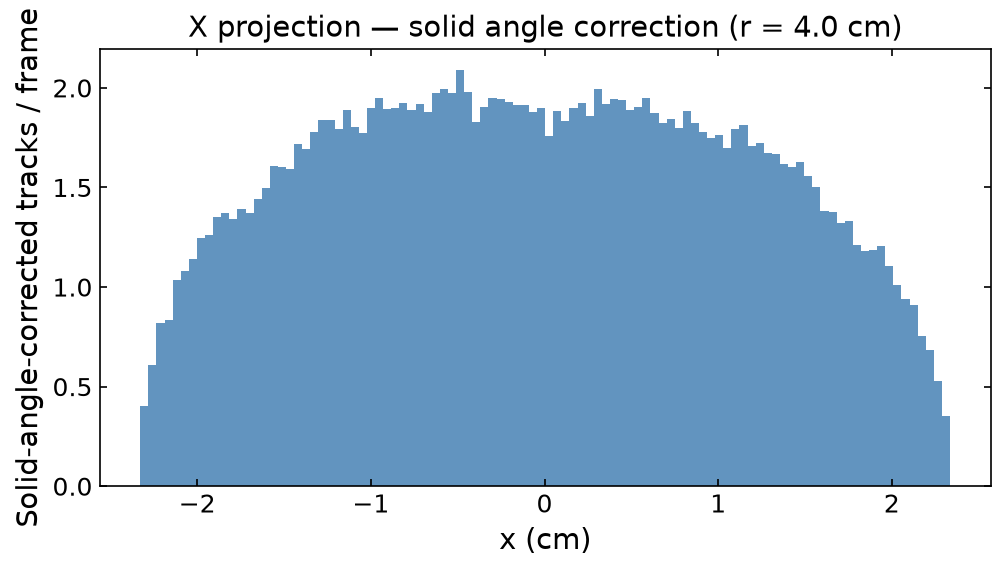

In [17]:
N_frames = len(data.frames)
# UPDATE: Corrected target-to-detector distance (r) from 6.0 cm to 4.0 cm.
# Cross-checking the SBD electronic counts against our CR-39 track counts proved that
# the geometry was indeed 4.0 cm, matching target yields within 5%.
r = 4.0  # cm, target-to-detector distance

# ── Bin centres from the 2D histogram ────────────────────────────────────────
xc = 0.5 * (xedges[:-1] + xedges[1:])   # shape (Nx,)
yc = 0.5 * (yedges[:-1] + yedges[1:])   # shape (Ny,)
XX, YY = np.meshgrid(xc, yc)             # shape (Ny, Nx)

# ── Solid angle weight per bin ────────────────────────────────────────────────
omega = r / (r**2 + XX**2 + YY**2)**1.5  # shape (Ny, Nx)

# ── Raw 2D counts (note: h2d[0] has shape (Nx, Ny), transpose to (Ny, Nx)) ──
counts2d = h2d[0].T                       # shape (Ny, Nx)

# ── Correct each bin then sum over Y ─────────────────────────────────────────
counts_corrected = counts2d / omega       # solid-angle-corrected counts per bin
cx_corrected = counts_corrected.sum(axis=0)  # sum over Y → shape (Nx,)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(xc, cx_corrected / N_frames, width=xedges[1]-xedges[0],
       color='steelblue', alpha=0.85)
ax.set_xlabel('x (cm)')
ax.set_ylabel('Solid-angle-corrected tracks / frame')
ax.set_title(f'X projection — solid angle correction (r = {r} cm)')
plt.tight_layout()
plt.show()

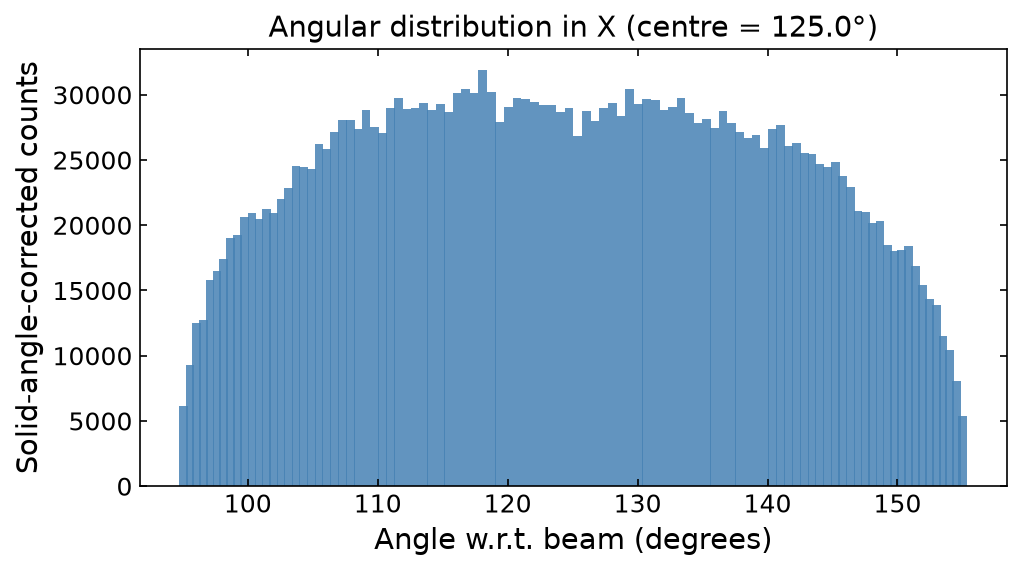

In [18]:
# UPDATE: Corrected target-to-detector distance (r) from 6.0 cm to 4.0 cm to align with the SBD cross-check.
r = 4.0        # cm, target-to-detector distance
theta0 = 125.0  # degrees, angle of piece centre w.r.t. beam

# ── Bin centres from the 2D histogram ────────────────────────────────────────
xc = 0.5 * (xedges[:-1] + xedges[1:])   # shape (Nx,)
yc = 0.5 * (yedges[:-1] + yedges[1:])   # shape (Ny,)
XX, YY = np.meshgrid(xc, yc)             # shape (Ny, Nx)

# ── Solid angle weight per bin ────────────────────────────────────────────────
omega = r / (r**2 + XX**2 + YY**2)**1.5  # shape (Ny, Nx)

# ── Raw 2D counts ─────────────────────────────────────────────────────────────
counts2d = h2d[0].T                       # shape (Ny, Nx)

# ── Correct each bin then sum over Y ─────────────────────────────────────────
counts_corrected = counts2d / omega
cx_corrected = counts_corrected.sum(axis=0)  # shape (Nx,)

# ── Convert x position to absolute angle w.r.t. beam ─────────────────────────
# xc is displacement from piece centre; arctan gives offset from piece normal
delta_theta = np.degrees(np.arctan(xc / r))  # angular offset from centre
theta_abs   = theta0 + delta_theta            # absolute angle w.r.t. beam
bw_deg      = np.degrees(np.arctan(bw_x / r))  # bar width in degrees

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(theta_abs, cx_corrected, width=bw_deg,
       color='steelblue', alpha=0.85)
ax.set_xlabel('Angle w.r.t. beam (degrees)')
ax.set_ylabel('Solid-angle-corrected counts')
ax.set_title(f'Angular distribution in X (centre = {theta0}°)')
plt.tight_layout()
plt.show()

## 8. Differential cross-section calculation



In [19]:
cross_DD = 20.56 #barns # But this is angle integrated 
differential_cross_DD = 20.56/(4*np.pi)

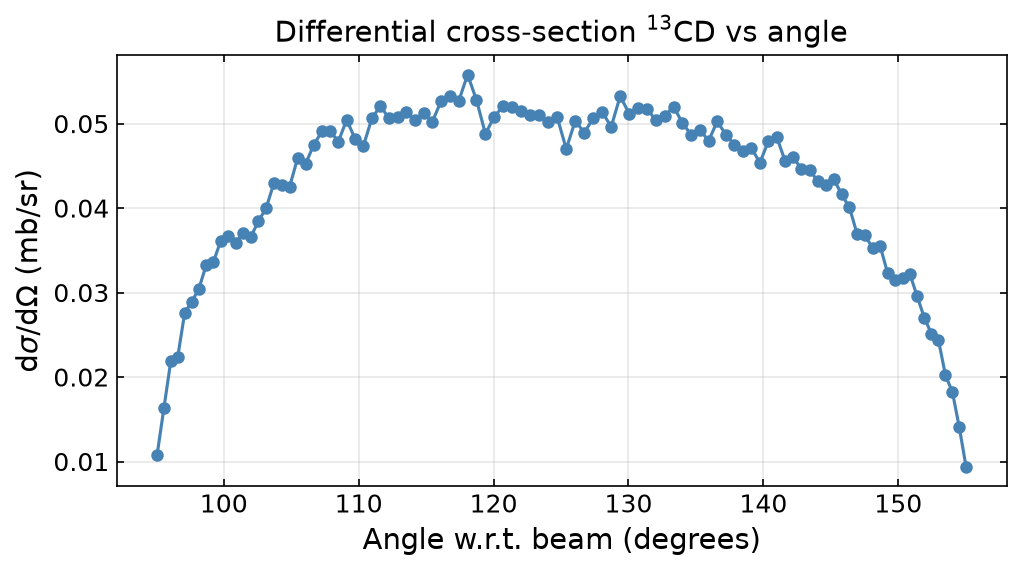

In [20]:
# ── Differential cross-section for 13CD ───────────────────────────────────────
normalization  = 0.172        # cm^2
counts_13CD    = cx_corrected # solid-angle-corrected counts from previous step
counts_DD      = 5438178
differential_cross_13CD = (counts_13CD / counts_DD) * (differential_cross_DD / normalization)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(theta_abs, differential_cross_13CD, 'o-', color='steelblue',
        markersize=5, linewidth=1.5)
ax.set_xlabel('Angle w.r.t. beam (degrees)')
ax.set_ylabel(r'd$\sigma$/d$\Omega$ (mb/sr)')
ax.set_title(r'Differential cross-section $^{13}$CD vs angle')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
(np.cos((np.pi*102)/180)**2 +np.cos((np.pi*148)/180)**2 + np.cos((np.pi*102)/180)*np.cos((np.pi*148)/180))/3

np.float64(0.31291065271330076)

In [22]:
0.31*6976*(4/6)**2

961.1377777777777

In [23]:
np.cos((np.pi*23)/180)**2

np.float64(0.8473291852294987)

In [24]:
1550*0.84

1302.0

In [25]:
3100*0.847

2625.7

In [26]:
600/(0.086)

6976.744186046512

## 8. Post-Cut Track Distributions

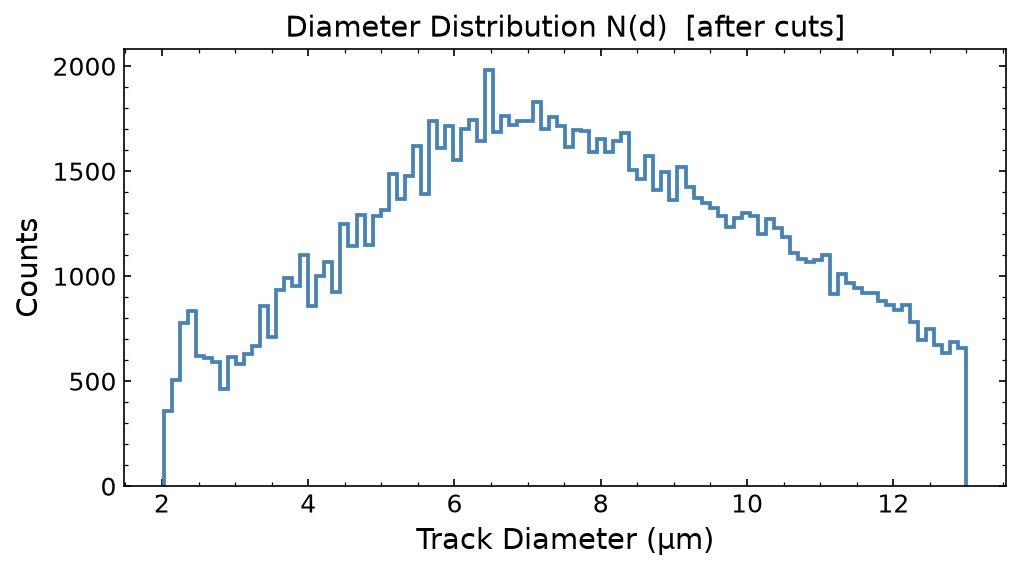

In [27]:
# ── Diameter distribution N(d) — after cuts ───────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(tracks['d'], bins=BINS_D, histtype='step', lw=1.8, color='steelblue')
ax.set_xlabel('Track Diameter (µm)')
ax.set_ylabel('Counts')
ax.set_title('Diameter Distribution N(d)  [after cuts]')
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

fig.tight_layout()
#fig.savefig(f'{PLOT_DIR}/04_diameter_distribution.png', dpi=300)
plt.show()

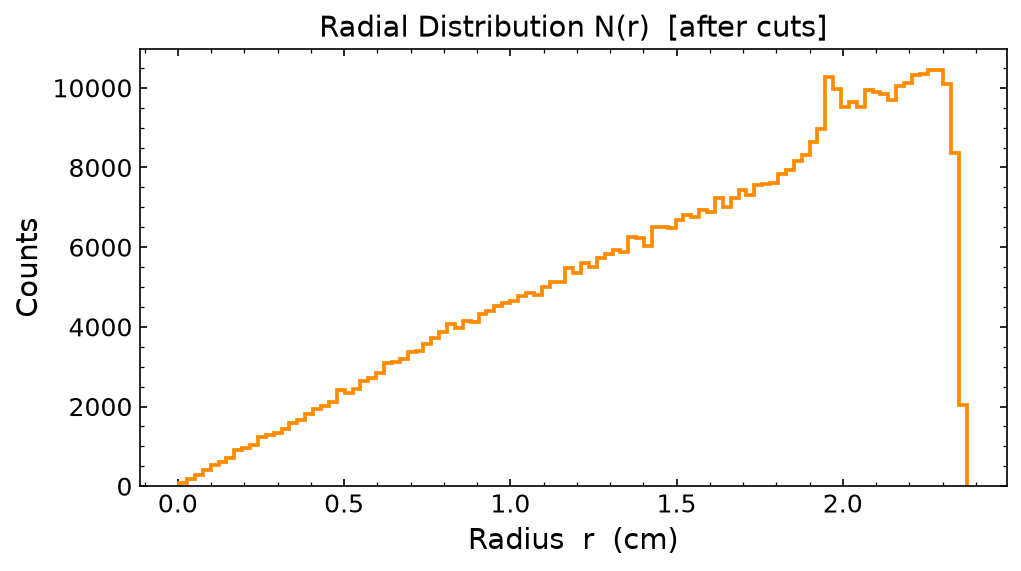

In [28]:
# ── Radial distribution N(r)  r = √(x² + y²) — after cuts ───────────────────
r = np.sqrt(x**2 + y**2)

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(r, bins=BINS_R, histtype='step', lw=1.8, color='darkorange')
ax.set_xlabel('Radius  r  (cm)')
ax.set_ylabel('Counts')
ax.set_title('Radial Distribution N(r)  [after cuts]')
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

fig.tight_layout()
#fig.savefig(f'{PLOT_DIR}/05_radial_distribution.png', dpi=300)
plt.show()

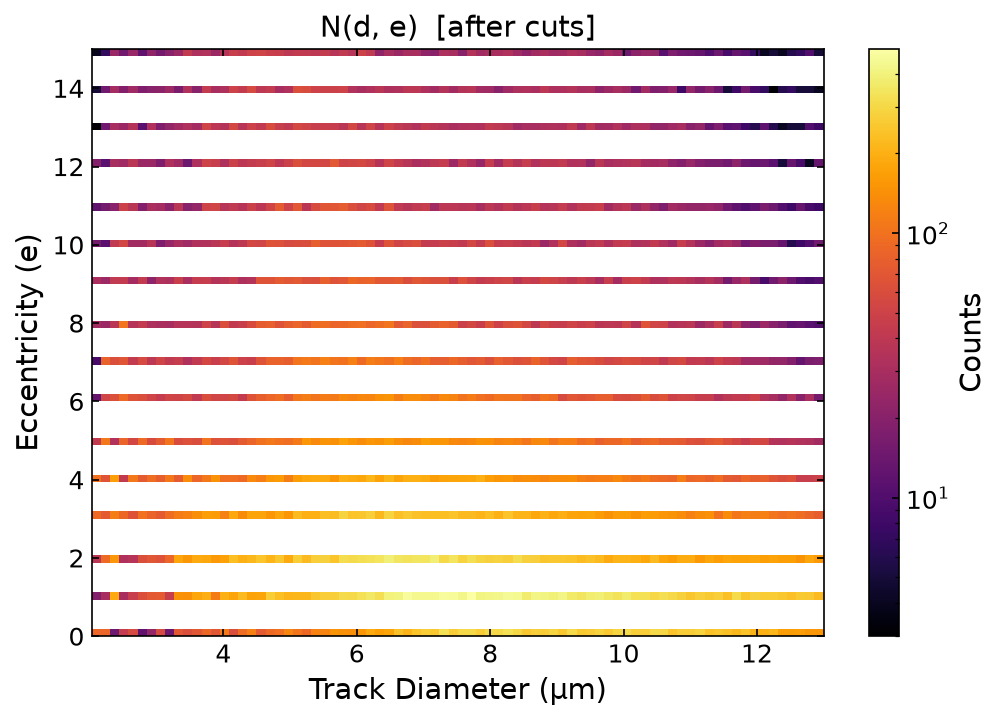

In [29]:
# ── 2D: diameter vs. eccentricity after cuts ──────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

h = ax.hist2d(tracks['d'], tracks['e'], bins=80, norm=LogNorm(), cmap='inferno')
fig.colorbar(h[3], ax=ax, label='Counts')

ax.set_xlabel('Track Diameter (µm)')
ax.set_ylabel('Eccentricity (e)')
ax.set_title('N(d, e)  [after cuts]')

fig.tight_layout()
#fig.savefig(f'{PLOT_DIR}/06_diameter_vs_eccentricity.png', dpi=300)
plt.show()

## 9. Summary Statistics

In [30]:

keys = ['num_x_frames', 'num_y_frames', ...]   # match the order of fields
h = dict(zip(keys, h))

# Now your original code will work:
n_frames_total = h['num_x_frames'] * h['num_y_frames']
n_frames_scanned = frames['number'].nunique()
n_frames_signal  = tracks[
    (tracks['x'] >= SIG_XMIN) & (tracks['x'] <= SIG_XMAX) &
    (tracks['y'] >= SIG_YMIN) & (tracks['y'] <= SIG_YMAX)
]['frame_number'].nunique()

# Scan area
px_cm   = h['pixel_size']          # cm per pixel
fw_cm   = h['frame_width']         # cm
fh_cm   = h['frame_height']        # cm
A_frame = fw_cm * fh_cm            # cm² per frame
A_total = n_frames_total * A_frame # total scanned area cm²

tpf = len(tracks) / n_frames_scanned  # tracks per frame (after cuts)

sep = '─' * 55
print(sep)
print('  CR-39 Analysis Summary')
print(sep)
print(f'  Scan grid              : {h["num_x_frames"]} × {h["num_y_frames"]} frames')
print(f'  Frame size             : {fw_cm*1e4:.1f} × {fh_cm*1e4:.1f} µm')
print(f'  Pixel size             : {px_cm*1e4:.4f} µm')
print(f'  Total scan area        : {A_total:.4f} cm²')
print(sep)
print(f'  Quality cuts applied   :')
print(f'    Diameter             : [{D_MIN}, {D_MAX}] µm')
print(f'    Eccentricity         : [{E_MIN}, {E_MAX}]')
print(f'    Contrast             : [{C_MIN}, {C_MAX}]')
print(f'    Spatial x            : [{X_MIN}, {X_MAX}] cm')
print(f'    Spatial y            : [{Y_MIN}, {Y_MAX}] cm')
print(sep)
print(f'  Tracks after cuts      : {len(tracks):,}')
print(f'  Tracks per frame       : {tpf:.3f}')
print(sep)
print(f'  Signal region          : x∈[{SIG_XMIN},{SIG_XMAX}]  y∈[{SIG_YMIN},{SIG_YMAX}] cm')
print(f'  Signal area            : {A_sig:.4f} cm²')
print(f'  Raw tracks in signal   : {N_sig_total:,}')
print(f'  Background strip area  : {A_bg:.4f} cm²  (scale={scale:.3f})')
print(f'  Scaled background      : {N_bg_scaled:.1f}')
print(f'  Background-subtr. N    : {N_signal_net:.1f} ± {sigma_net:.1f}')
print(sep)
print(f'  Plots saved to: {os.path.abspath(PLOT_DIR)}')
print(sep)

ValueError: operands could not be broadcast together with shapes (80,80) (81,) 

In [ ]:
2536*1.45*1e-3